# ASL Perfusion Quantification

This notebook demonstrates arterial spin labelling (ASL) perfusion quantification using Digital Reference Objects (DROs).

## Learning Objectives

- Understand the General Kinetic Model (GKM) for ASL
- Generate synthetic pCASL data with known perfusion values
- Explore the effect of transit time on the ASL signal
- Understand multi-PLD acquisition strategies

## Background

The ASL difference signal $\Delta M$ depends on cerebral blood flow (CBF) through:

$$\Delta M = 2 M_{0,b} \cdot f \cdot T_1' \cdot \alpha \cdot e^{-\delta/T_{1,b}} \cdot (1 - e^{-\tau/T_1'}) \cdot e^{-(t-\tau-\delta)/T_1'}$$

where:
- $f$ is perfusion rate (CBF)
- $\delta$ is arterial transit time (ATT)
- $\tau$ is label duration
- $\alpha$ is labelling efficiency
- $T_{1,b}$ is blood T1

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qmri.dro import perfusion

## 1. Basic pCASL Signal Generation

Let's generate a pCASL phantom with typical brain perfusion.

In [2]:
# Generate pCASL phantom with grey matter CBF
phantom = perfusion.generate_pcasl(
    perfusion_rate=60.0,  # ml/100g/min (typical GM)
    m0=1000.0,
    transit_time=1.0,  # seconds
    label_duration=1.8,
    post_label_delay=1.8,
    label_efficiency=0.85,
    t1_blood=1.65,
    t1_tissue=1.3,
    snr=50.0,
    seed=42,
)

print("Ground Truth:")
print(f"  CBF: {phantom.ground_truth['perfusion_rate'].value} ml/100g/min")
print(f"  ATT: {phantom.ground_truth['transit_time'].value} s")
print()
print("Acquisition Parameters:")
for key, value in phantom.acquisition_params.items():
    print(f"  {key}: {value}")
print()
print(f"Control signal: {float(phantom.control):.1f}")
print(f"Label signal: {float(phantom.label):.1f}")
print(f"ΔM: {float(phantom.control) - float(phantom.label):.1f}")

Ground Truth:
  CBF: 60.0 ml/100g/min
  ATT: 1.0 s

Acquisition Parameters:
  label_duration: 1.8
  post_label_delay: 1.8
  label_efficiency: 0.85
  partition_coefficient: 0.9
  t1_blood: 1.65

Control signal: 1006.3
Label signal: 1009.8
ΔM: -3.5


## 2. Perfusion Contrast

The ASL contrast is very small (typically 1-2% of M0). Let's visualise this.

/tmp/ipykernel_72287/3413252637.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{l}\n({c})" for l, c in zip(labels, cbf_values)])


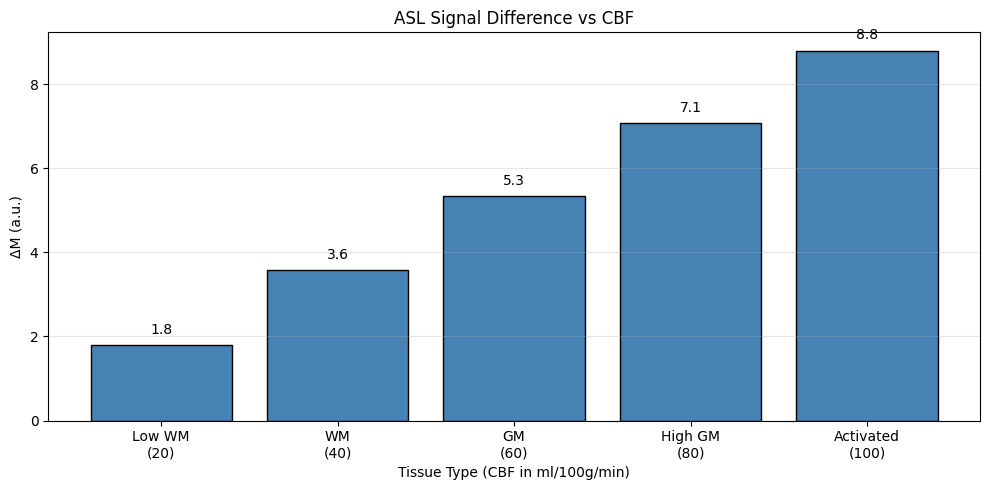

ΔM as % of M0: 0.88%


In [3]:
# Compare different CBF values
cbf_values = [20, 40, 60, 80, 100]  # ml/100g/min
labels = ["Low WM", "WM", "GM", "High GM", "Activated"]

delta_m_values = []
for cbf in cbf_values:
    p = perfusion.generate_pcasl(perfusion_rate=cbf, m0=1000.0)
    delta_m = float(p.control) - float(p.label)
    delta_m_values.append(delta_m)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, delta_m_values, color="steelblue", edgecolor="black")

# Add value labels
for bar, val in zip(bars, delta_m_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{val:.1f}",
        ha="center",
        va="bottom",
    )

ax.set_ylabel("ΔM (a.u.)")
ax.set_xlabel("Tissue Type (CBF in ml/100g/min)")
ax.set_title("ASL Signal Difference vs CBF")

# Add CBF values to x-labels
ax.set_xticklabels([f"{l}\n({c})" for l, c in zip(labels, cbf_values)])

ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"ΔM as % of M0: {delta_m_values[-1] / 1000 * 100:.2f}%")

## 3. Transit Time Effects

The arterial transit time (ATT) significantly affects the ASL signal. Let's explore this.

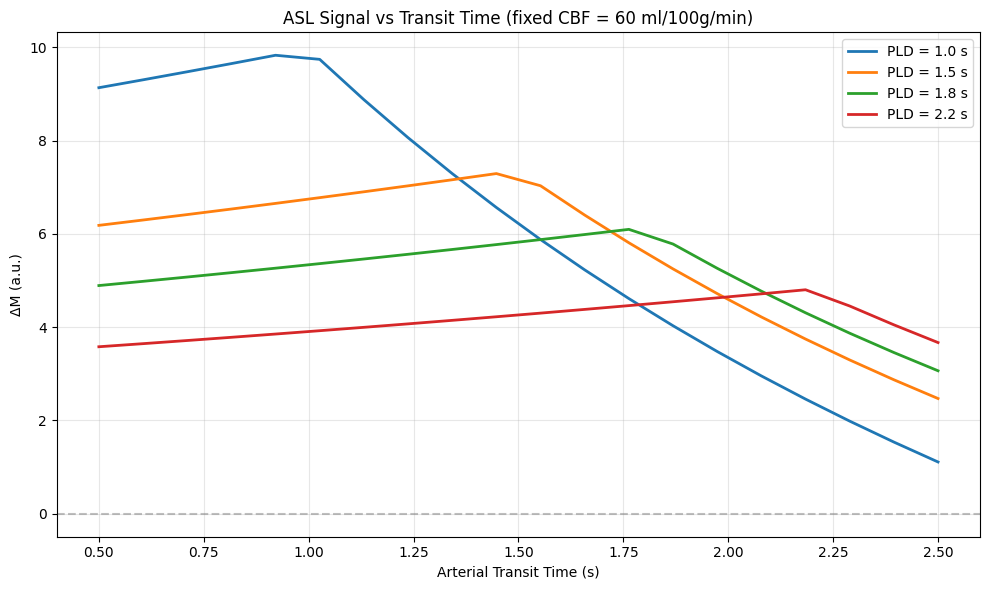

In [4]:
# Vary transit time
att_values = np.linspace(0.5, 2.5, 20)
pld_values = [1.0, 1.5, 1.8, 2.2]

fig, ax = plt.subplots(figsize=(10, 6))

for pld in pld_values:
    delta_m_vs_att = []
    for att in att_values:
        p = perfusion.generate_pcasl(
            perfusion_rate=60.0,
            m0=1000.0,
            transit_time=att,
            post_label_delay=pld,
        )
        delta_m_vs_att.append(float(p.control) - float(p.label))

    ax.plot(att_values, delta_m_vs_att, linewidth=2, label=f"PLD = {pld} s")

ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Arterial Transit Time (s)")
ax.set_ylabel("ΔM (a.u.)")
ax.set_title("ASL Signal vs Transit Time (fixed CBF = 60 ml/100g/min)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Key observations:
- Signal drops when ATT > PLD (bolus hasn't arrived)
- Longer PLD captures longer transit times but signal decays
- This is why multi-PLD acquisitions are valuable

## 4. Multi-Voxel Perfusion Map

In [5]:
# Create a CBF map (simplified brain-like pattern)
cbf_map = np.array(
    [
        [20, 30, 40, 50, 50, 40, 30, 20],
        [30, 50, 60, 70, 70, 60, 50, 30],
        [40, 60, 80, 90, 90, 80, 60, 40],
        [40, 60, 80, 90, 90, 80, 60, 40],
        [30, 50, 60, 70, 70, 60, 50, 30],
        [20, 30, 40, 50, 50, 40, 30, 20],
    ],
    dtype=float,
)

# Generate phantom
phantom_2d = perfusion.generate_pcasl(
    perfusion_rate=cbf_map,
    m0=1000.0,
    snr=30.0,
    seed=42,
)

# Calculate difference
delta_m_map = phantom_2d.control - phantom_2d.label

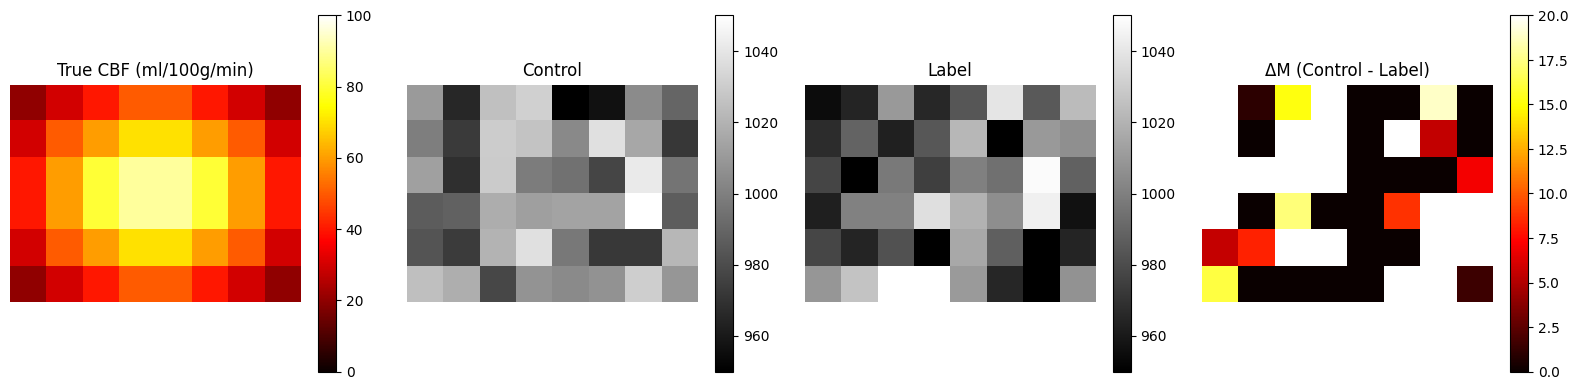

In [6]:
# Visualise
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

im0 = axes[0].imshow(cbf_map, cmap="hot", vmin=0, vmax=100)
axes[0].set_title("True CBF (ml/100g/min)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(phantom_2d.control, cmap="gray", vmin=950, vmax=1050)
axes[1].set_title("Control")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(phantom_2d.label, cmap="gray", vmin=950, vmax=1050)
axes[2].set_title("Label")
plt.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(delta_m_map, cmap="hot", vmin=0, vmax=20)
axes[3].set_title("ΔM (Control - Label)")
plt.colorbar(im3, ax=axes[3])

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Signal-to-Noise Considerations

ASL has inherently low SNR because ΔM is small. Let's examine this.

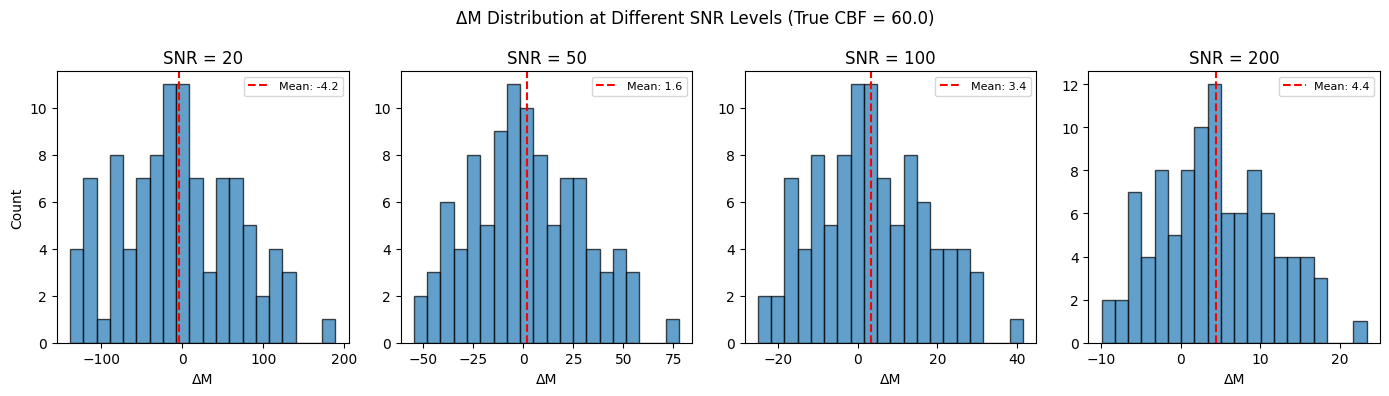

In [7]:
# Compare different SNR levels
snr_levels = [20, 50, 100, 200]
true_cbf = 60.0
n_repeats = 100

fig, axes = plt.subplots(1, len(snr_levels), figsize=(14, 4))

for ax, snr in zip(axes, snr_levels):
    delta_m_samples = []
    for seed in range(n_repeats):
        p = perfusion.generate_pcasl(
            perfusion_rate=true_cbf,
            m0=1000.0,
            snr=snr,
            seed=seed,
        )
        delta_m_samples.append(float(p.control) - float(p.label))

    ax.hist(delta_m_samples, bins=20, edgecolor="black", alpha=0.7)
    ax.axvline(
        np.mean(delta_m_samples),
        color="red",
        linestyle="--",
        label=f"Mean: {np.mean(delta_m_samples):.1f}",
    )
    ax.set_title(f"SNR = {snr}")
    ax.set_xlabel("ΔM")
    if ax == axes[0]:
        ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle(f"ΔM Distribution at Different SNR Levels (True CBF = {true_cbf})")
plt.tight_layout()
plt.show()

## Summary

Key takeaways from this notebook:

1. **ASL contrast is small**: Typically 1-2% of M0
2. **Transit time matters**: Must choose PLD > ATT for signal
3. **Multi-PLD helps**: Captures range of transit times
4. **SNR is critical**: Averaging (or longer scans) is essential
5. **DROs enable validation**: Test quantification before clinical use